In [6]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [7]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""peru""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [39]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_MANE_CADD_251110.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

existing_annos = ['gpn_score', 'gpn_star_llr_calibrated_mean', 'cadd_raw']

# plof_cols = ['loftee_hc', 'loftee_lc']
plof_cols = ['loftee_hc', 'loftee_lc', 'consequence_start_lost', 'consequence_stop_lost']

anno = (
    anno
    .filter(
        # Filter for coding variants
        ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True)) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region'])
        .union(set(existing_annos))
        .union(set(plof_cols))
    )
    .with_columns(
        dubious_plof = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    )
    .collect(engine='streaming')
)

anno = anno.filter(
    pl.any_horizontal(plof_cols)
)

anno

id,loftee_lc,region,consequence_stop_lost,consequence_start_lost,cadd_raw,gpn_star_llr_calibrated_mean,loftee_hc,gpn_score,dubious_plof
str,i8,str,i32,i32,f32,f32,i8,f32,bool
"""chr1:158635912:C:T""",0,"""ENSG00000163554""",0,0,5.678086,-9.271162,1,-8.51,false
"""chr19:40451457:G:A""",0,"""ENSG00000090013""",0,0,7.113487,-6.75589,1,-7.41,false
"""chr2:79087612:T:A""",0,"""ENSG00000172023""",0,1,0.98857,-0.337312,0,-1.68,true
"""chr22:28687974:G:A""",0,"""ENSG00000183765""",0,0,8.880945,-7.12172,1,-5.19,false
"""chr1:158639944:T:A""",0,"""ENSG00000163554""",0,0,7.820711,-4.125523,1,-3.74,false
…,…,…,…,…,…,…,…,…,…
"""chr10:116089743:G:A""",0,"""ENSG00000151892""",0,0,10.51435,-12.171133,1,-8.8,false
"""chr2:112777986:C:A""",0,"""ENSG00000115008""",0,0,5.137421,-10.469576,1,-9.25,false
"""chr10:116125220:C:T""",0,"""ENSG00000151892""",0,0,5.625401,-12.393619,1,-10.45,false


## LOFTEE only

In [ ]:
lof_df = (
    anno
    .filter(
        (pl.col('loftee_hc') == 1) | (pl.col('loftee_lc') == 1)
    )
    .unpivot(
        # index=['id', 'region', 'loftee_hc', 'loftee_lc'],
        index=['id', 'region', 'loftee_hc'],
        variable_name='annotation',
        value_name='annotation_score',
    )
    .unpivot(
        index = ['id', 'region', 'annotation', 'annotation_score'],
        variable_name='loftee_type',
        value_name='LOFTEE_HC',
    )
    .join(
        anno_config_df,
        on='annotation',
        how='inner'
    )
    .with_columns(
        LOFTEE_type = (
            pl.when(pl.col("LOFTEE_HC")==1)
            .then(pl.lit('LOFTEE HC'))
            .otherwise(pl.lit('LOFTEE LC'))
        ),
        annotation_score_dircorr = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

# (
#     ggplot(
#         lof_df,
#         aes(y='annotation_score_dircorr', x='LOFTEE_type', fill='label')
#     )
#     + geom_boxplot(width=0.75, alpha=0.75)
#     + facet_wrap('~label', scales='free_y', ncol=3)
#     + scale_fill_manual(values=color_dict)
#     + labs(x='')
#     + theme_minimal()
#     + theme(
#         figure_size=(7, 5.5),
#         axis_text_x=element_text(rotation=45, hjust=1),
#         axis_text=element_text(size=13),
#         axis_title=element_text(size=13),
#         legend_text=element_text(size=13),
#         legend_title=element_text(size=13),
#     )
# )

id,region,annotation,annotation_score,loftee_type,LOFTEE_HC,category,color,label,annotation_dir,LOFTEE_type,annotation_score_dircorr
str,str,str,f64,str,i8,str,str,str,i8,str,f32
"""chr1:158635912:C:T""","""ENSG00000163554""","""cadd_raw""",5.678086,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,"""LOFTEE HC""",5.678086
"""chr19:40451457:G:A""","""ENSG00000090013""","""cadd_raw""",7.113487,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,"""LOFTEE HC""",7.113487
"""chr22:28687974:G:A""","""ENSG00000183765""","""cadd_raw""",8.880945,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,"""LOFTEE HC""",8.880945
"""chr1:158639944:T:A""","""ENSG00000163554""","""cadd_raw""",7.820711,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,"""LOFTEE HC""",7.820711
"""chr12:124786505:T:G""","""ENSG00000073060""","""cadd_raw""",5.148724,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,"""LOFTEE HC""",5.148724
…,…,…,…,…,…,…,…,…,…,…,…
"""chr10:116089743:G:A""","""ENSG00000151892""","""gpn_score""",-8.8,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,"""LOFTEE HC""",8.8
"""chr2:112777986:C:A""","""ENSG00000115008""","""gpn_score""",-9.25,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,"""LOFTEE HC""",9.25
"""chr10:116125220:C:T""","""ENSG00000151892""","""gpn_score""",-10.45,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,"""LOFTEE HC""",10.45


## Other pLoF

In [ ]:
plof_df = (
    anno
    .unpivot(
        index=['id', 'region', 'dubious_plof', 'loftee_lc', 'loftee_hc'],
        variable_name='annotation',
        value_name='annotation_score',
    )
    .unpivot(
        index = ['id', 'region', 'annotation', 'annotation_score'],
        variable_name='loftee_type',
        value_name='loftee_score',
    )
    .filter(
        pl.col('loftee_score') == 1
    )
    .join(
        anno_config_df,
        on='annotation',
        how='inner'
    )
    .with_columns(
        annotation_score_dircorr = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

plof_df

id,region,annotation,annotation_score,loftee_type,loftee_score,category,color,label,annotation_dir,annotation_score_dircorr
str,str,str,f64,str,i8,str,str,str,i8,f32
"""chr2:79087612:T:A""","""ENSG00000172023""","""cadd_raw""",0.98857,"""dubious_plof""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.98857
"""chr19:40465686:C:A""","""ENSG00000090013""","""cadd_raw""",4.310061,"""dubious_plof""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,4.310061
"""chr19:40465687:A:G""","""ENSG00000090013""","""cadd_raw""",4.12157,"""dubious_plof""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,4.12157
"""chr2:79085218:A:G""","""ENSG00000172023""","""cadd_raw""",0.896158,"""dubious_plof""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.896158
"""chr2:79087612:T:C""","""ENSG00000172023""","""cadd_raw""",1.401247,"""dubious_plof""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,1.401247
…,…,…,…,…,…,…,…,…,…,…
"""chr2:27827628:G:C""","""ENSG00000171174""","""gpn_score""",-7.27,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,7.27
"""chr10:116089743:G:A""","""ENSG00000151892""","""gpn_score""",-8.8,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,8.8
"""chr2:112777986:C:A""","""ENSG00000115008""","""gpn_score""",-9.25,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,9.25


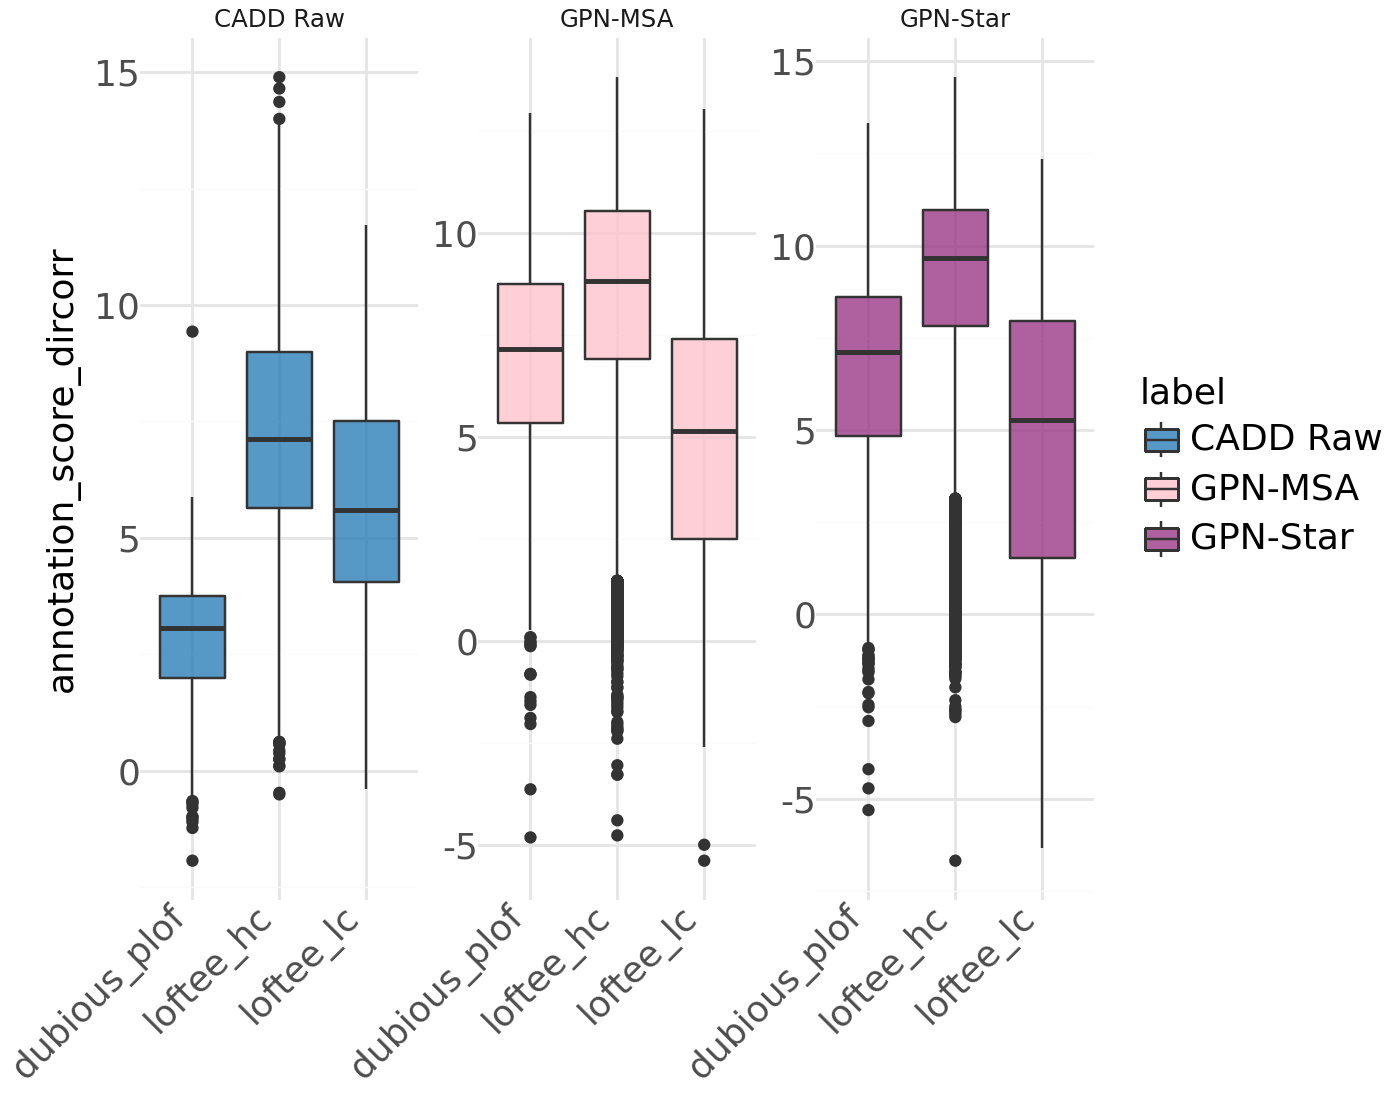

In [38]:
color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(
        plof_df,
        aes(y='annotation_score_dircorr', x='loftee_type', fill='label')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + facet_wrap('~label', scales='free_y', ncol=3)
    + scale_fill_manual(values=color_dict)
    + labs(x='')
    + theme_minimal()
    + theme(
        figure_size=(7, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)